## Análise de Vendas de um Supermercado

### Objetivo
Este projeto tem como objetivo analisar os dados de vendas de um supermercado fictício, 
identificando padrões de comportamento de clientes e o desempenho das filiais, a fim de 
gerar insights que possam apoiar decisões estratégicas de negócio.

### Sobre a base de dados
A base contém 1000 registros de vendas, com informações sobre filial, cidade, tipo de 
cliente (Member/Normal), gênero, produto, categoria, preço unitário, quantidade, imposto, 
valor total e pontos de recompensa.

### Perguntas que este projeto busca responder
- Clientes do tipo Member gastam mais do que clientes Normal?
- Existe diferença de desempenho entre as filiais? Se sim, por quê?
- Quais categorias de produto têm maior participação no faturamento?

### Estrutura da análise
1. Análise de clientes (perfil de compra Member vs Normal)
2. Análise de filiais (faturamento, ticket médio, ranking)
3. Análise de produtos (categorias mais relevantes)
4. Conclusões e recomendações

## Importação das Bibliotecas

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


## Funções auxiliares

In [2]:
# Função auxiliar para formatar valores monetários no padrão brasileiro
def formatar_moeda(valor):
    return (f"R$ {valor:,.2f}"
        .replace(",", "X")
        .replace(".", ",")
        .replace("X", ".")
    )


## Carregamento e inspeção inicial dos dados

Nesta etapa será realizada uma análise inicial da base para compreender sua estrutura, tipos de dados, valores ausentes e possíveis registros duplicados.

In [3]:
# Carrega a base
vendas_df = pd.read_csv("data/sales.csv")


In [4]:
# Mostra as 5 primeiras linhas da base
display(vendas_df.head())

,sale_id,branch,city,customer_type,gender,product_name,product_category,unit_price,quantity,tax,total_price,reward_points
0,1,A,New York,Member,Male,Shampoo,Personal Care,5.50,3,1.16,17.66,1
1,2,B,Los Angeles,Normal,Female,Notebook,Stationery,2.75,10,1.93,29.43,0
2,3,A,New York,Member,Female,Apple,Fruits,1.20,15,1.26,19.26,1
3,4,A,Chicago,Normal,Male,Detergent,Household,7.80,5,2.73,41.73,0
4,5,B,Los Angeles,Member,Female,Orange Juice,Beverages,3.50,7,1.72,26.22,2


In [5]:
# Verifica estrutura e tipos de dados da base
vendas_df.info()


<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   sale_id           1000 non-null   int64  
 1   branch            1000 non-null   str    
 2   city              1000 non-null   str    
 3   customer_type     1000 non-null   str    
 4   gender            1000 non-null   str    
 5   product_name      1000 non-null   str    
 6   product_category  1000 non-null   str    
 7   unit_price        1000 non-null   float64
 8   quantity          1000 non-null   int64  
 9   tax               1000 non-null   float64
 10  total_price       1000 non-null   float64
 11  reward_points     1000 non-null   int64  
dtypes: float64(3), int64(3), str(6)
memory usage: 93.9 KB


In [6]:
# Verifica quantidade de valores ausentes por coluna
valores_nulos = vendas_df.isnull().sum()

print(valores_nulos)

sale_id             0
branch              0
city                0
customer_type       0
gender              0
product_name        0
product_category    0
unit_price          0
quantity            0
tax                 0
total_price         0
reward_points       0
dtype: int64


In [7]:
# Verifica quantidade de registros duplicados
duplicados = vendas_df.duplicated().sum()

print(f"Quantidade de registros duplicados: {duplicados}")

Quantidade de registros duplicados: 0


## Análise exploratória inicial

In [8]:
# Cria um DataFrame para exibir a quantidade de valores únicos de colunas específicas
resumo_valores_unicos = pd.DataFrame({
    "Colunas": [
        "branch",
        "city",
        "customer_type",
        "gender",
        "product_category"
    ],
    "Quantidade de valores únicos": [
        vendas_df["branch"].nunique(),
        vendas_df["city"].nunique(),
        vendas_df["customer_type"].nunique(),
        vendas_df["gender"].nunique(),
        vendas_df["product_category"].nunique()
    ]
})

display(resumo_valores_unicos)


,Colunas,Quantidade de valores únicos
0,branch,2
1,city,3
2,customer_type,2
3,gender,2
4,product_category,5


## Análise de clientes

### Dados analisados

In [9]:
# Conta quantas compras foram feitas por cada tipo de cliente e transforma o resultado em um DataFrame
distribuicao_clientes = vendas_df["customer_type"].value_counts().reset_index()

# cria uma coluna de representação percentual
distribuicao_clientes["percentual"] = distribuicao_clientes["count"] / distribuicao_clientes["count"].sum() * 100

display(distribuicao_clientes.style.format({
    "percentual": "{:.2f}%"
    })
    .hide(axis="index")
)


customer_type,count,percentual
Member,516,51.60%
Normal,484,48.40%


### Visualização dos Resultados

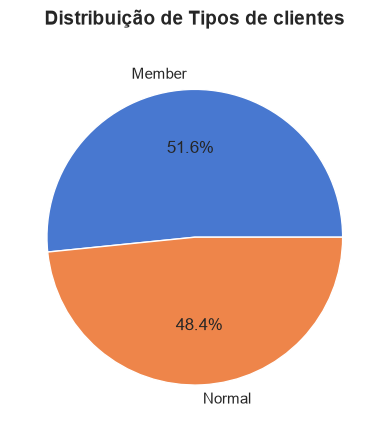

In [10]:
# Define o tema para os graficos
sns.set_theme(style='dark', palette='muted')

plt.pie(distribuicao_clientes["count"], labels=distribuicao_clientes["customer_type"], autopct="%.1f%%")

plt.title("Distribuição de Tipos de clientes", fontsize=14, weight="bold", pad=20)


plt.show()

### Relatório da Análise

As compras realizadas por clientes do tipo Member representam uma pequena maioria das transações (51,6%) e também são responsáveis por um faturamento superior ao dos clientes classificados como Normal. Esse comportamento indica que os clientes Member possuem maior relevância para o faturamento do supermercado, possivelmente relacionado ao programa de fidelidade, que pode incentivar compras de maior valor por transação.

In [11]:
# Agrupa os dados pelo tipo de cliente, calcula a média do valor total de compras de cada um
gasto_medio = vendas_df.groupby("customer_type")["total_price"].mean().reset_index()

display(gasto_medio.style.format({
    "total_price": formatar_moeda
    })
    .hide(axis="index")
)

customer_type,total_price
Member,"R$ 122,51"
Normal,"R$ 114,40"


### Visualização dos Resultados

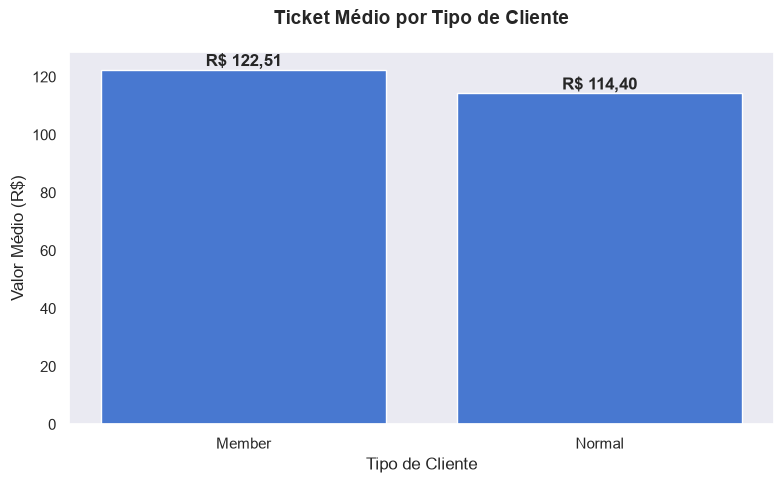

In [12]:
fig, ax = plt.subplots(figsize=(8, 5))

barras = ax.bar(gasto_medio["customer_type"], gasto_medio["total_price"])

ax.set_title("Ticket Médio por Tipo de Cliente", fontsize=14, weight="bold", pad=20)
ax.set_ylabel("Valor Médio (R$)")
ax.set_xlabel("Tipo de Cliente")

ax.bar_label(barras, labels=[formatar_moeda(valor) for valor in gasto_medio["total_price"]], fontweight="bold")

plt.tight_layout()
plt.show()

### Relatório da Análise

Embora o volume de transações seja equilibrado entre os dois perfis, os clientes Member apresentam um ticket médio cerca de R$ 8,11 superior ao dos clientes Normal. Esse maior gasto por compra garante aos membros uma fatia mais expressiva no faturamento, sinalizando uma associação positiva entre o programa de fidelidade e a geração de valor por transação.

## Análise de filiais

### Dados analisados

In [13]:
# Faturamento total por filial
faturamento_filial = vendas_df.groupby("branch")["total_price"].sum().reset_index(name="faturamento_total")

display(faturamento_filial.style.format({
    "faturamento_total": formatar_moeda
    })
)


,branch,faturamento_total
0,A,"R$ 82.811,64"
1,B,"R$ 35.772,26"


### Visualização dos Resultados

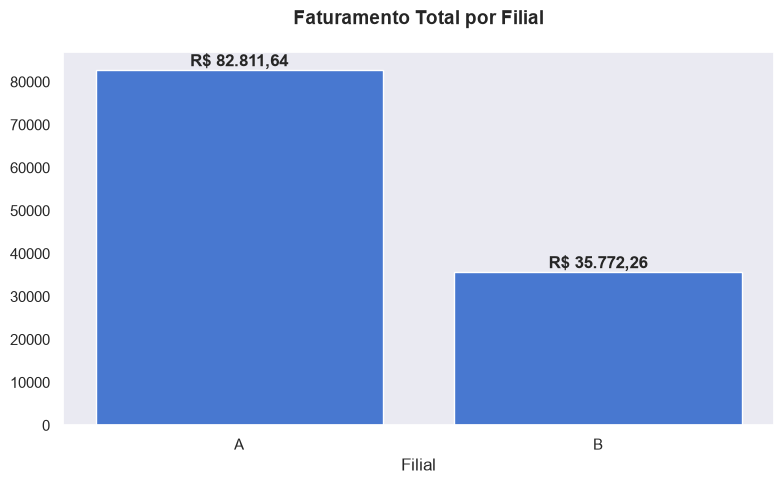

In [14]:
fig, ax = plt.subplots(figsize=(8, 5))

barras = ax.bar(faturamento_filial["branch"], faturamento_filial["faturamento_total"])

ax.set_title("Faturamento Total por Filial", fontsize=14, weight="bold", pad=20)
ax.set_xlabel("Filial")

ax.bar_label(barras, labels=[formatar_moeda(valor) for valor in faturamento_filial["faturamento_total"]], fontweight="bold")

plt.tight_layout()
plt.show()

In [15]:
# proporção de vendas correlacioado com o faturamento por loja
display(pd.crosstab(vendas_df["branch"], vendas_df["customer_type"]))

proporcao_vendas_tipo_cliente = (vendas_df.groupby("branch")["customer_type"].value_counts(normalize=True).mul(100)).reset_index()

display(proporcao_vendas_tipo_cliente.style.format({
    "proportion": "{:.2f} %"
    })
.hide(axis="index")
)

customer_type,Member,Normal
branch,,
A,355,319
B,161,165


branch,customer_type,proportion
A,Member,52.67 %
A,Normal,47.33 %
B,Normal,50.61 %
B,Member,49.39 %


### Relatório da Análise

De acordo com os dados analisados, a filial A apresenta faturamento superior à filial B, impulsionado principalmente pelo maior volume total de vendas.

Além do volume, a composição do público impacta diretamente esse resultado. A filial A registra não apenas maior quantidade absoluta, mas também uma participação proporcional superior de vendas para clientes do tipo Member. Como esse grupo possui um ticket médio mais alto que os clientes Normal, essa concentração de clientes de maior valor alavanca a receita da unidade.

In [16]:
# Ticket médio por filial
ticket_medio_filial = vendas_df.groupby("branch")["total_price"].mean().reset_index(name="ticket_medio")

display(ticket_medio_filial.style.format({
    "ticket_medio": formatar_moeda
    })
    .hide(axis="index")
)


branch,ticket_medio
A,"R$ 122,87"
B,"R$ 109,73"


### Visualização dos Resultados

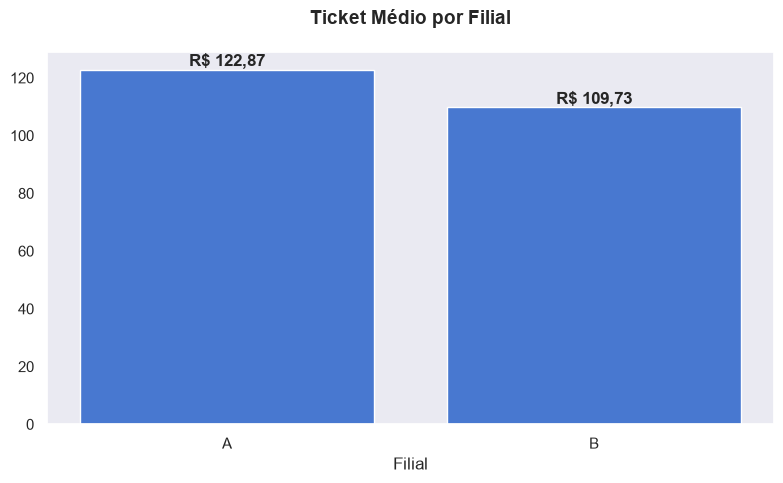

In [17]:
fig, ax = plt.subplots(figsize=(8, 5))

barras = ax.bar(ticket_medio_filial["branch"], ticket_medio_filial["ticket_medio"])

ax.set_title("Ticket Médio por Filial", fontsize=14, weight="bold", pad=20)
ax.set_xlabel("Filial")

ax.bar_label(barras, labels=[formatar_moeda(valor) for valor in ticket_medio_filial["ticket_medio"]], fontweight="bold")

plt.tight_layout()
plt.show()

In [18]:
# Quantidade de vendas por filial
qtd_vendas_filial = vendas_df.groupby("branch")["sale_id"].count().reset_index(name="quantidade_vendas")

qtd_vendas_filial["percentual_vendas"] = qtd_vendas_filial["quantidade_vendas"] / qtd_vendas_filial["quantidade_vendas"].sum() * 100

display(qtd_vendas_filial.style.format({
    "percentual_vendas": "{:.2f} %"
    })
    .hide(axis="index")
)

branch,quantidade_vendas,percentual_vendas
A,674,67.40 %
B,326,32.60 %


### Relatório da Análise

A filial A lidera o faturamento impulsionada pelo maior volume total de vendas e pela forte presença do segmento Member, que registra maior gasto médio por transação.

Assim, a diferença de receita entre as unidades deriva não apenas da quantidade de operações, mas da composição do público: a maior proporção de clientes Member eleva o ticket médio global da filial em comparação aos clientes Normal.


In [19]:
# Cria uma tabela dinâmica 
faturamento_tipo = vendas_df.pivot_table(
    index="branch", 
    columns="customer_type", 
    values="total_price", 
    aggfunc="sum"
).reset_index() # Transforma o índice "bold" de volta em uma coluna normal

# Formata a exibição dos valores para o padrão monetário (R$)
display(faturamento_tipo.style.format({
    "Member": "R$ {:,.2f}",
    "Normal": "R$ {:,.2f}",
    })
    .hide(axis="index") # Oculta o índice numérico para deixar a tabela mais limpa
)

branch,Member,Normal
A,"R$ 45,288.76","R$ 37,522.88"
B,"R$ 17,924.87","R$ 17,847.39"


## Análise de produtos

### Volume de Vendas vs. Faturamento Real

In [20]:
# Agrupa os dados por categoria de produto e soma duas colunas simultaneamente: 
analise_produtos = vendas_df.groupby("product_category")[["quantity", "total_price"]].sum()

# Cria uma nova coluna chamada "faturamento_por_unidade" para descobrir o valor médio de cada item.
analise_produtos["faturamento_por_unidade"] = analise_produtos["total_price"] / analise_produtos["quantity"]

# Ordena a tabela dando prioridade para quem teve o maior faturamento
analise_produtos = analise_produtos.sort_values(["total_price", "quantity"], ascending=False).reset_index()

# Exibe a tabela formatando os valores financeiros para o padrão de moeda (R$ com duas casas decimais)
display(analise_produtos.style.format({
    "total_price": formatar_moeda,
    "faturamento_por_unidade": formatar_moeda
    })
    .hide(axis="index")
)

product_category,quantity,total_price,faturamento_por_unidade
Personal Care,2278,"R$ 27.050,18","R$ 11,87"
Fruits,2286,"R$ 26.197,45","R$ 11,46"
Beverages,1952,"R$ 22.983,32","R$ 11,77"
Household,1908,"R$ 21.615,84","R$ 11,33"
Stationery,1913,"R$ 20.737,11","R$ 10,84"


### Visualização dos Resultados

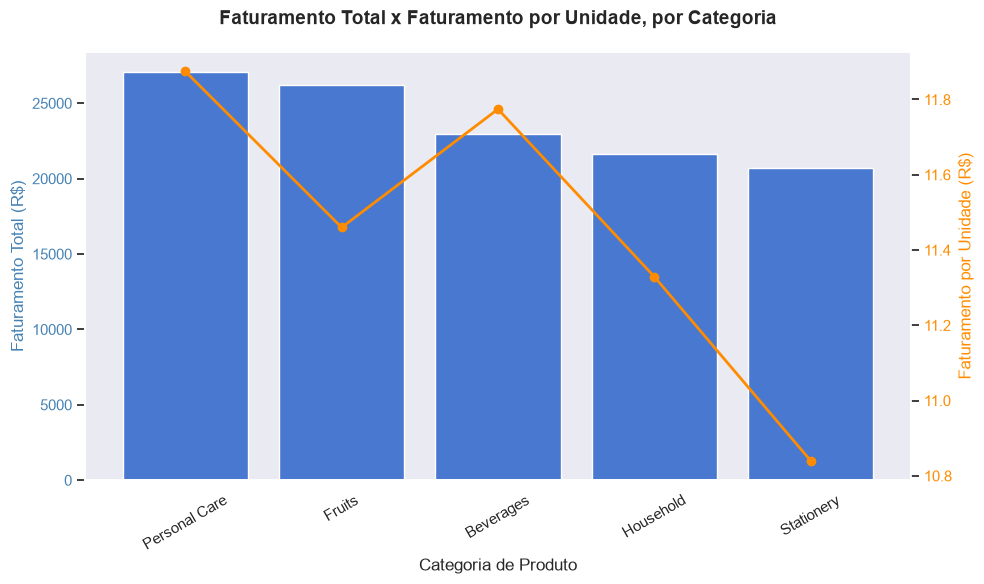

In [21]:
fig, ax1 = plt.subplots(figsize=(10, 6))

# Barras faturamento total por categoria
ax1.bar(analise_produtos["product_category"], analise_produtos["total_price"])
ax1.set_xlabel("Categoria de Produto")
ax1.set_ylabel("Faturamento Total (R$)", color="steelblue")
ax1.tick_params(axis="y", labelcolor="steelblue")
ax1.tick_params(axis="x", rotation=30)

# Linha no eixo secundário faturamento por unidade
ax2 = ax1.twinx()
ax2.plot(analise_produtos["product_category"], analise_produtos["faturamento_por_unidade"],
          color="darkorange", marker="o", linewidth=2)
ax2.set_ylabel("Faturamento por Unidade (R$)", color="darkorange")
ax2.tick_params(axis="y", labelcolor="darkorange")

plt.title("Faturamento Total x Faturamento por Unidade, por Categoria", fontsize=14, weight="bold", pad=20)
fig.tight_layout()
plt.show()

### Relatório da Análise

A análise por categorias demonstra que Personal Care liderou o faturamento no período, somando R$ 27.050,18, enquanto Fruits registrou o maior volume de vendas, com 2.286 unidades comercializadas.

Embora a diferença na quantidade vendida entre ambas seja pequena, a liderança em receita de Personal Care é explicada por seu maior preço médio por item. O resultado evidencia que o volume de vendas isolado não garante o maior faturamento, sendo o valor unitário um fator decisivo para a receita final.

As demais categorias mantiveram volumes e faturamentos homogêneos, indicando uma distribuição equilibrada das vendas entre os principais segmentos do supermercado.

### Análise do Ticket Médio por Categoria de Produto

In [22]:
# Agrupa os dados por categoria de produto e calcula a média do preço total.
ticket_medio_categorias = vendas_df.groupby("product_category")["total_price"].mean().reset_index(name="ticket_medio_por_categoria")

# Ordena a tabela com base no ticket médio calculado, do maior para o menor
ticket_medio_categorias = ticket_medio_categorias.sort_values(["ticket_medio_por_categoria"], ascending=False).reset_index(drop=True)

# Exibe a tabela final formatando o valor do ticket médio como moeda 
display(ticket_medio_categorias.style.format({
    "ticket_medio_por_categoria": formatar_moeda
    })
    .hide(axis="index")
)

product_category,ticket_medio_por_categoria
Personal Care,"R$ 130,05"
Fruits,"R$ 125,35"
Beverages,"R$ 122,91"
Household,"R$ 109,17"
Stationery,"R$ 104,73"


### Visualização dos Resultados

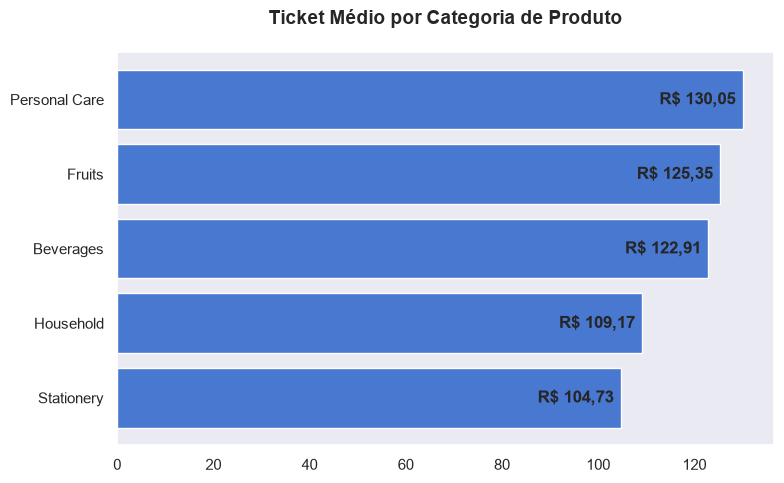

In [23]:
fig, ax = plt.subplots(figsize=(8, 5))

barras = ax.barh(ticket_medio_categorias["product_category"], ticket_medio_categorias["ticket_medio_por_categoria"])

ax.bar_label(barras, padding=-60, fontweight="bold", labels=[formatar_moeda(valor) for valor in ticket_medio_categorias["ticket_medio_por_categoria"]])

ax.set_title('Ticket Médio por Categoria de Produto', fontsize=14, weight='bold', pad=20)

ax.invert_yaxis()

plt.tight_layout()
plt.show()

### Relatório da Análise

A análise do ticket médio confirma que Personal Care registra o maior valor por transação (R$ 130,05), seguida por Fruits (R$ 125,35) e Beverages (R$ 122,91).

Esse dado complementa a análise anterior, justificando por que Personal Care lidera a receita mesmo sem o maior volume de vendas. Cada transação da categoria gera uma receita unitária superior, compensando a menor quantidade de itens comercializados.

Em contrapartida, Household e Stationery registraram os menores tickets médios do período. Embora ajudem no volume global de operações, suas compras possuem menor peso financeiro individual para o negócio.

### Faturamento por Categoria e Tipo de Cliente

In [24]:
# Cria uma tabela dinâmica cruzando a categoria do produto (linhas) com o tipo de cliente (colunas)
# e soma o valor total de faturamento para cada cruzamento
consumo_por_categoria = vendas_df.pivot_table(
    index="product_category", 
    columns="customer_type", 
    values="total_price", 
    aggfunc="sum"
)

# Cria uma nova coluna chamada "total", somando o faturamento dos clientes Member e Normal
consumo_por_categoria["total"] = consumo_por_categoria["Member"] + consumo_por_categoria["Normal"]

# Ordena a tabela do maior para o menor faturamento total e reseta o índice 
# (isso transforma o "bold" de volta em uma coluna comum)
consumo_por_categoria = consumo_por_categoria.sort_values(["total"], ascending=False).reset_index()

# Exibe a tabela formatando as três colunas financeiras para o padrão de moeda (R$) 
# e oculta o índice numérico lateral para deixar a visualização mais limpa
display(consumo_por_categoria.style.format({
    "Member": formatar_moeda,
    "Normal": formatar_moeda,
    "total": formatar_moeda
    })
    .hide(axis="index")
)


product_category,Member,Normal,total
Personal Care,"R$ 15.370,60","R$ 11.679,58","R$ 27.050,18"
Fruits,"R$ 14.045,72","R$ 12.151,73","R$ 26.197,45"
Beverages,"R$ 11.807,00","R$ 11.176,32","R$ 22.983,32"
Household,"R$ 11.613,86","R$ 10.001,98","R$ 21.615,84"
Stationery,"R$ 10.376,45","R$ 10.360,66","R$ 20.737,11"


### Visualização dos Resultados

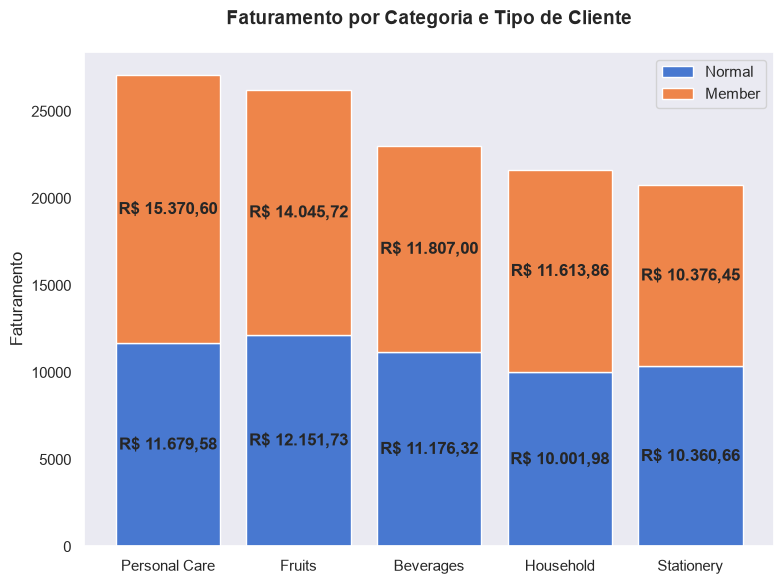

In [25]:
fig, ax = plt.subplots(figsize=(8, 6))

barras_normal = ax.bar(consumo_por_categoria["product_category"], consumo_por_categoria["Normal"], label="Normal")
barras_member = ax.bar(consumo_por_categoria["product_category"], consumo_por_categoria["Member"], bottom=consumo_por_categoria["Normal"], label="Member" )

labels_normal = [formatar_moeda(valor) for valor in consumo_por_categoria["Normal"]]
labels_member = [formatar_moeda(valor) for valor in consumo_por_categoria["Member"]]

ax.bar_label(barras_normal, labels=labels_normal, fontweight="bold", label_type="center")
ax.bar_label(barras_member, labels=labels_member, fontweight="bold", label_type="center")

ax.set_title("Faturamento por Categoria e Tipo de Cliente", fontsize=14, weight="bold", pad=20)
ax.set_ylabel("Faturamento")
ax.legend()

plt.tight_layout()
plt.show()

### Relatório da Análise

A análise cruzada entre categoria e perfil de consumidor revela que os clientes Member geram maior faturamento em todos os segmentos do supermercado, consolidando os achados anteriores sobre o impacto desse público na receita global.

A categoria Personal Care registrou o maior faturamento vindo desse grupo (R$ 15.370,60), seguida por Fruits e Household. Em contrapartida, Stationery apresentou a menor variação entre os grupos Member e Normal, sinalizando um comportamento de consumo mais homogêneo entre os perfis.

Esses dados indicam que o programa de fidelidade exerce maior influência em categorias de maior valor agregado, funcionando como um alavancador estratégico do faturamento nesses segmentos.

### Filiais por Produto

In [26]:
# Agrupa os dados por categoria de produto e filial, somando o faturamento
produtos_filiais = vendas_df.groupby(["product_category", "branch"])["total_price"].sum().reset_index()

# Cria uma coluna temporária ("bold") calculando o faturamento TOTAL da categoria (Filial A + B)
# O "bold"sum"bold" é usado aqui para espalhar essa soma por todas as linhas sem reduzi-las
produtos_filiais["total_categoria"] = produtos_filiais.groupby("product_category")["total_price"].transform("sum")

# Ordena os dados: primeiro pelas categorias que mais faturaram (maior para o menor)
# e, em caso de empate na categoria, ordena pela filial (A depois B)
produtos_filiais = produtos_filiais.sort_values(by=["total_categoria", "branch"], ascending=[False, True])

# Exclui a coluna temporária "bold", pois ela serviu apenas para ajudar na ordenação
produtos_filiais = produtos_filiais.drop(columns=["total_categoria"]).reset_index(drop=True)

# Calcula a porcentagem (fatia) de cada filial no faturamento da sua respectiva categoria
produtos_filiais["participacao_categoria"] = (
    produtos_filiais["total_price"] / 
    produtos_filiais.groupby("product_category")["total_price"].transform("sum") * 100
)

# Exibe a tabela formatada com símbolo de moeda e porcentagem
display(produtos_filiais.style.format({
    "total_price": formatar_moeda,
    "participacao_categoria": "{:.2f} %"
    })
    .hide(axis="index")
)


product_category,branch,total_price,participacao_categoria
Personal Care,A,"R$ 18.686,17",69.08 %
Personal Care,B,"R$ 8.364,01",30.92 %
Fruits,A,"R$ 17.332,88",66.16 %
Fruits,B,"R$ 8.864,57",33.84 %
Beverages,A,"R$ 14.938,87",65.00 %
Beverages,B,"R$ 8.044,45",35.00 %
Household,A,"R$ 15.257,64",70.59 %
Household,B,"R$ 6.358,20",29.41 %
Stationery,A,"R$ 16.596,08",80.03 %
Stationery,B,"R$ 4.141,03",19.97 %


### Visualização dos Resultados

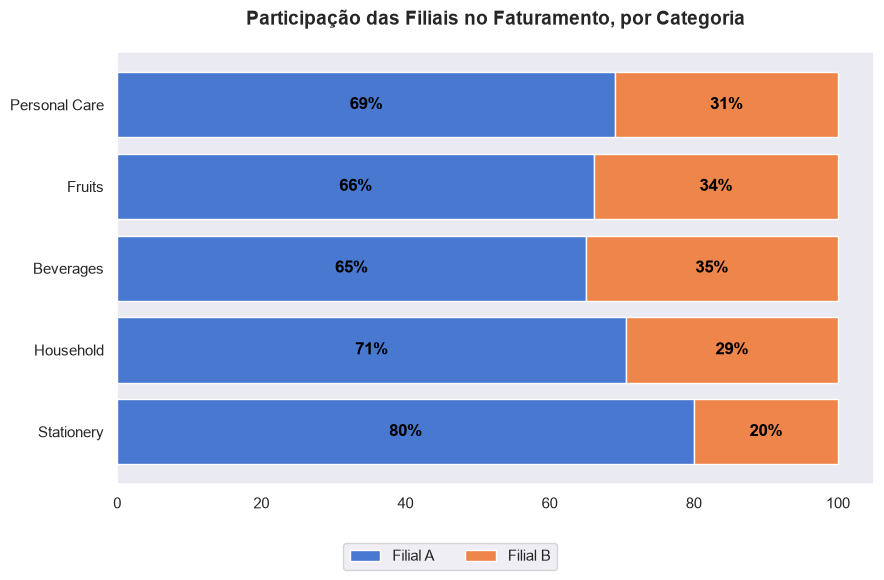

In [27]:
# Cria uma tabela pivô com a participação percentual de cada filial no faturamento de cada categoria
participacao_pivot = produtos_filiais.pivot(index="product_category", columns="branch", values="participacao_categoria")

# Mantém a mesma ordem de categorias usada na tabela acima (por faturamento total, do maior para o menor)
ordem_categorias = produtos_filiais.groupby("product_category")["total_price"].sum().sort_values(ascending=False).index
participacao_pivot = participacao_pivot.loc[ordem_categorias]

fig, ax = plt.subplots(figsize=(9, 6))
esquerda = 0
for filial in ["A", "B"]:
    valores = participacao_pivot[filial]
    barras = ax.barh(participacao_pivot.index, valores, left=esquerda, label=f"Filial {filial}")
    ax.bar_label(barras, labels=[f"{v:.0f}%" for v in valores], label_type="center", color="black", fontweight="bold")
    esquerda = esquerda + valores

ax.set_title("Participação das Filiais no Faturamento, por Categoria", fontsize=14, weight="bold", pad=20)
ax.legend(loc="upper center", bbox_to_anchor=(0.44, -0.12), ncol=2)

ax.invert_yaxis()

plt.tight_layout()
plt.show()

### Relatório da análise

A análise cruzada entre faturamento, categoria e filial confirma a liderança da Filial A, que superou a Filial B em todos os segmentos avaliados (Personal Care, Fruits, Beverages, Household e Stationery).

As disparidades mais acentuadas ocorreram em Stationery (R$ 16.596,08 na Filial A contra R$ 4.141,03 na Filial B) e Personal Care (R$ 18.686,17 contra R$ 8.364,01 — mais que o dobro da segunda unidade). Por outro lado, a categoria Fruits apresentou a menor variação relativa, sinalizando um desempenho mais parelho entre as filiais.

Esses dados indicam que o domínio da Filial A vai além do volume bruto de transações: a unidade demonstra maior capacidade de geração de receita em categorias estratégicas de maior valor agregado.

## Resumo Executivo de Desempenho das Filiais

In [28]:
# Unifica (merge) vários DataFrames em um só, usando a coluna "bold" (filial) como chave de ligação
ranking_filiais = faturamento_filial.merge(qtd_vendas_filial, on="branch").merge(ticket_medio_filial, on="branch").merge(faturamento_tipo, on="branch")

# Calcula qual a porcentagem do faturamento que veio de clientes "bold"
ranking_filiais["participacao_member"] = (ranking_filiais["Member"] / ranking_filiais["faturamento_total"]) * 100

# Ordena o ranking final pelo faturamento total (do maior para o menor) e reseta o índice
ranking_filiais = ranking_filiais.sort_values("faturamento_total", ascending=False).reset_index(drop=True)

# Calcula o percentual de representatividade de cada filial sobre o faturamento TOTAL do negócio
ranking_filiais["participacao_faturamento"] = (ranking_filiais["faturamento_total"] / ranking_filiais["faturamento_total"].sum()) * 100

# Insere uma nova coluna chamada "bold" logo no início (posição 0) baseada no índice do DataFrame
ranking_filiais.insert(0, "ranking", ranking_filiais.index + 1)

# Renomeia as colunas para deixá-las amigáveis para leitura por outras pessoas no relatório final
ranking_filiais_final = (
    ranking_filiais
    .rename(columns={
        "ranking": "Ranking",
        "branch": "Filial",
        "faturamento_total": "Faturamento Total",
        "quantidade_vendas": "Quantidade de Vendas",
        "percentual_vendas": "Percentual de Vendas",
        "ticket_medio": "Ticket Médio",
        "Member": "Faturamento Member",
        "Normal": "Faturamento Normal",
        "participacao_member": "Particiação de Clientes Members",
        "participacao_faturamento": "Percentual de Faturamento"
    })
)

# Formata os valores apenas para exibição
display(
    ranking_filiais_final.style
    .format({
        "Faturamento Total": formatar_moeda,
        "Percentual de Vendas": "{:.2f} %",
        "Ticket Médio": formatar_moeda,
        "Faturamento Member": formatar_moeda,
        "Faturamento Normal": formatar_moeda,
        "Particiação de Clientes Members": "{:.2f} %",
        "Percentual de Faturamento": "{:.2f} %"
    })
    .hide(axis="index")  
)


Ranking,Filial,Faturamento Total,Quantidade de Vendas,Percentual de Vendas,Ticket Médio,Faturamento Member,Faturamento Normal,Particiação de Clientes Members,Percentual de Faturamento
1,A,"R$ 82.811,64",674,67.40 %,"R$ 122,87","R$ 45.288,76","R$ 37.522,88",54.69 %,69.83 %
2,B,"R$ 35.772,26",326,32.60 %,"R$ 109,73","R$ 17.924,87","R$ 17.847,39",50.11 %,30.17 %


### Conclusões e Insights

Este projeto explorou o comportamento de vendas de um supermercado por meio de Análise Exploratória de Dados (EDA), identificando padrões de consumo, disparidades entre filiais e oportunidades de negócio.

Principais achados da análise:

**Domínio da Filial A**: A unidade concentrou 67,4% do volume de vendas e ~70% do faturamento total, impulsionada tanto pela quantidade de transações quanto pelo maior ticket médio.

**Impacto da Fidelização**: Clientes Member apresentaram ticket médio superior ao dos clientes Normal, registrando forte participação no faturamento global e alta presença na Filial A.

**Volume vs. Valor**: A categoria Personal Care liderou em receita e ticket médio, enquanto Fruits registrou o maior volume de itens vendidos.

**Liderança por Categoria**: A Filial A superou a Filial B em 100% dos segmentos, com as maiores disparidades observadas em Personal Care e Stationery.

Em suma, a vantagem competitiva da Filial A resulta da combinação entre alto volume de vendas, ticket médio elevado e forte desempenho nas categorias de maior valor agregado.